In [ ]:
#filter the orthogroups
#author: Sheng-Kai Hsu
#created: 2024.06.06
#last edited: 2025.03.31


In [ ]:
rm(list = ls())
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")

In [ ]:
helixer_OG = read.table(file.path(PHYLOGWAS_ROOT, "output/OrthoFinder/Results_Jun06/Orthogroups/Orthogroups.GeneCount.tsv"),header =T)

In [41]:
dim(helixer_OG)

[1] 99140    34

In [42]:
colnames(helixer_OG)

[1] "Orthogroup"                              
 [2] "ASEM_AUS1_V1.0.aa"                       
 [3] "ASM160227v1.aa"                          
 [4] "ASM1927943v1.aa"                         
 [5] "ASM1935983v1.aa"                         
 [6] "ASM711570v1.aa"                          
 [7] "Aet_v5.0.aa"                             
 [8] "Alomy_genome_v1.aa"                      
 [9] "Av.Kellogg1287_8.REFERENCE.PanAnd.1.0.aa"
[10] "Brachypodium_distachyon_v3.0.aa"         
[11] "DiExil.aa"                               
[12] "Eleusine_coracana_v1.0.aa"               
[13] "Embrapa_Uruz_1.0.aa"                     
[14] "IRGSP.1.0.aa"                            
[15] "KIB_Aluo_1.aa"                           
[16] "KIB_Gang_2.aa"                           
[17] "KIB_Mbac_1.aa"                           
[18] "KIB_Ogla_1.aa"                           
[19] "KIB_Pedu_3.aa"                           
[20] "KIB_Rgui_2.aa"                           
[21] "P.vaginatum_v3.1.aa"                     
[22] "P.virgatum_v5.aa"                        
[23] "Pp.Kellogg1297.DRAFT.PanAnd.1.0.aa"      
[24] "Puccinellia_tenuiflora_refer_1.0.aa"     
[25] "Rt.Layton_Zhong169.DRAFT.PanAnd.1.0.aa"  
[26] "Salk_teff_dabbi_3.0.aa"                  
[27] "Setaria_italica_v2.0.aa"                 
[28] "Sorghum_bicolor_NCBIv3.aa"               
[29] "TSU_Scap_1.aa"                           
[30] "Zm.B73.REFERENCE.NAM.5.0.aa"             
[31] "lpBroSter1.1.aa"                         
[32] "lpPhrAust1.1.aa"                         
[33] "mabamboo_1.0.aa"                         
[34] "Total"

In [43]:
# helixer_OG_filtered = helixer_OG[,-idx]
helixer_OG_filtered = helixer_OG

In [44]:
helixer_OG_filtered = helixer_OG_filtered[-which(apply(helixer_OG_filtered[,-c(1,ncol(helixer_OG_filtered))],1,function(x) all(x<=1))),-c(1,ncol(helixer_OG_filtered))]

In [45]:
dim(helixer_OG_filtered)

[1] 87841    32

In [ ]:
helixerGeneCount = read.table(file.path(PHYLOGWAS_ROOT, "output/helixerGeneCounts_poaceaeRepAssemblies.txt"),sep = ":")

In [47]:
helixerGeneCount[,1] = gsub('.aa.fa','',helixerGeneCount[,1])

In [86]:
helixerGeneCount

V1,V2
<chr>,<int>
Aet_v5.0,134291
Alomy_genome_v1,70273
ASEM_AUS1_V1.0,47211
ASM160227v1,40809
ASM1927943v1,36844
ASM1935983v1,36488
ASM711570v1,50315
Av-Kellogg1287_8-REFERENCE-PanAnd-1.0,44975
Brachypodium_distachyon_v3.0,31709


In [ ]:
library(ape)
spTre = read.tree(file.path(PHYLOGWAS_ROOT, "output/PoaceaeTree_angiosperm353_astral.nwk"))
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [60]:
spTre.rooted$tip.label[grep("Pp-",spTre.rooted$tip.label)]

[1] "Pp-Kellogg1297-DRAFT-PanAnd-1.0"

In [61]:
spTre.subset = keep.tip(spTre.rooted,helixerGeneCount[,1])

In [ ]:
metadata = read.csv(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_2025.04.07.csv"),header = T)

spTre.subset.renamed=spTre.subset
merge_tab5=data.frame(assemblyID=spTre.subset$tip.label)
merge_tab5=merge(merge_tab5,metadata,by = "assemblyID")
merge_tab5=merge_tab5[!duplicated(merge_tab5$assemblyID),]
rownames(merge_tab5)=merge_tab5$assemblyID
merge_tab5=merge_tab5[spTre.subset$tip.label,]
merge_tab5$spTaxa = paste(merge_tab5$assemblyID,merge_tab5$correctSpecies,sep = ":")
spTre.subset.renamed$tip.label[!is.na(merge_tab5$correctSpecies)] = merge_tab5$correctSpecies[!is.na(merge_tab5$correctSpecies)]

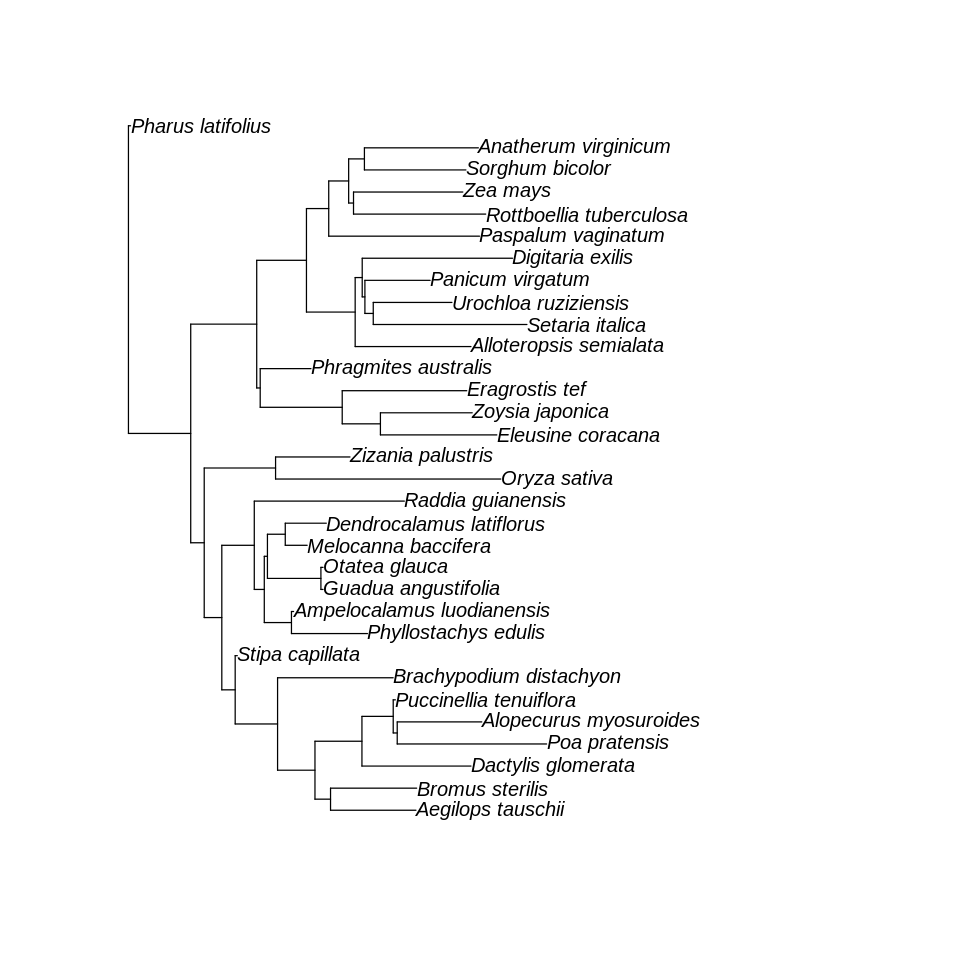

In [77]:
plot(spTre.subset.renamed)

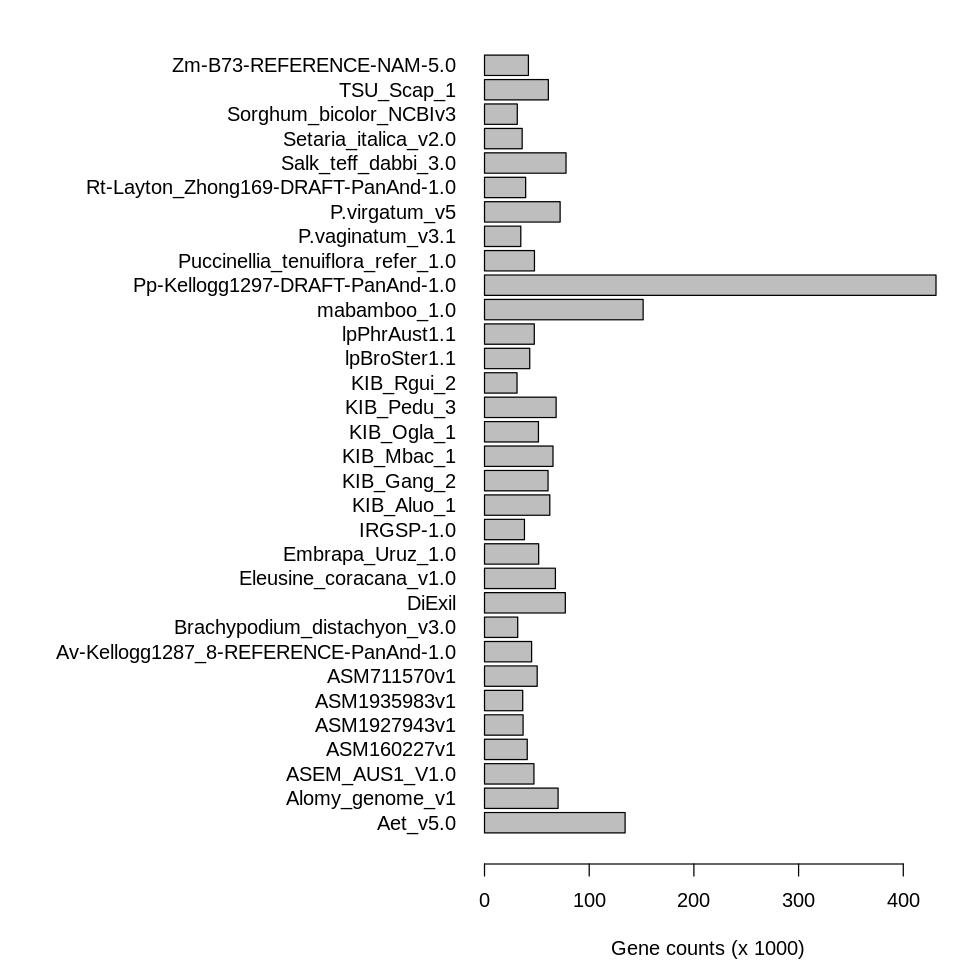

In [37]:
options(repr.plot.width=8, repr.plot.height=8)
par(mar = c(4,20,1,1))
barplot(helixerGeneCount[,2]/1000,names.arg = helixerGeneCount[,1],horiz = T,las = 1,
        xlab = "Gene counts (x 1000)")
        

In [87]:
library(ggtree)
library(ggplot2)

In [165]:
names(helixerGeneCount) = c("label","count")
helixerGeneCount[,2] = helixerGeneCount[,2]/1000

In [132]:
library(ggnewscale)

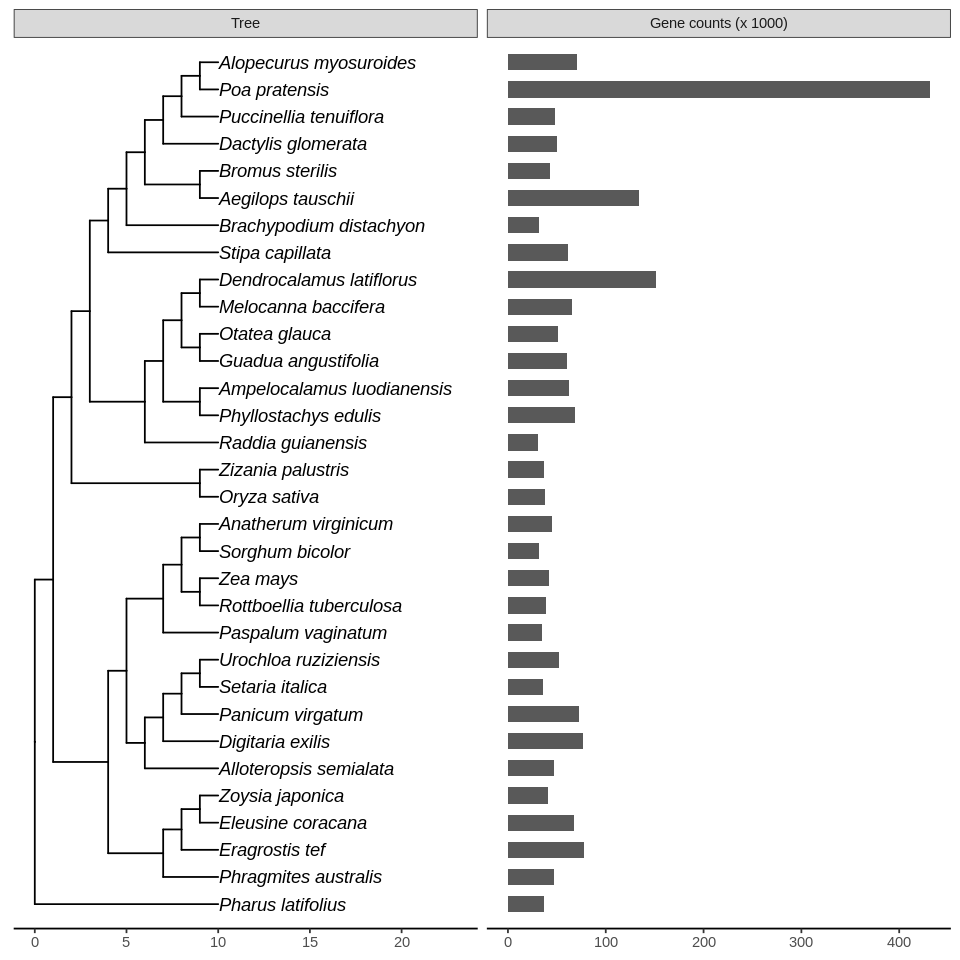

In [166]:
p = ggtree(spTre.subset,branch.length = "none") %<+% merge_tab5
p = p + geom_tiplab(mapping = aes(label = correctSpecies),fontface = 'italic')
p + geom_facet(panel = "Gene counts (x 1000)", data = helixerGeneCount, geom = geom_col,
            mapping = aes(x = count), orientation = 'y', width = .6)+
    theme_tree2(legend.position="none")+
    xlim_tree(xlim = c(0,23))

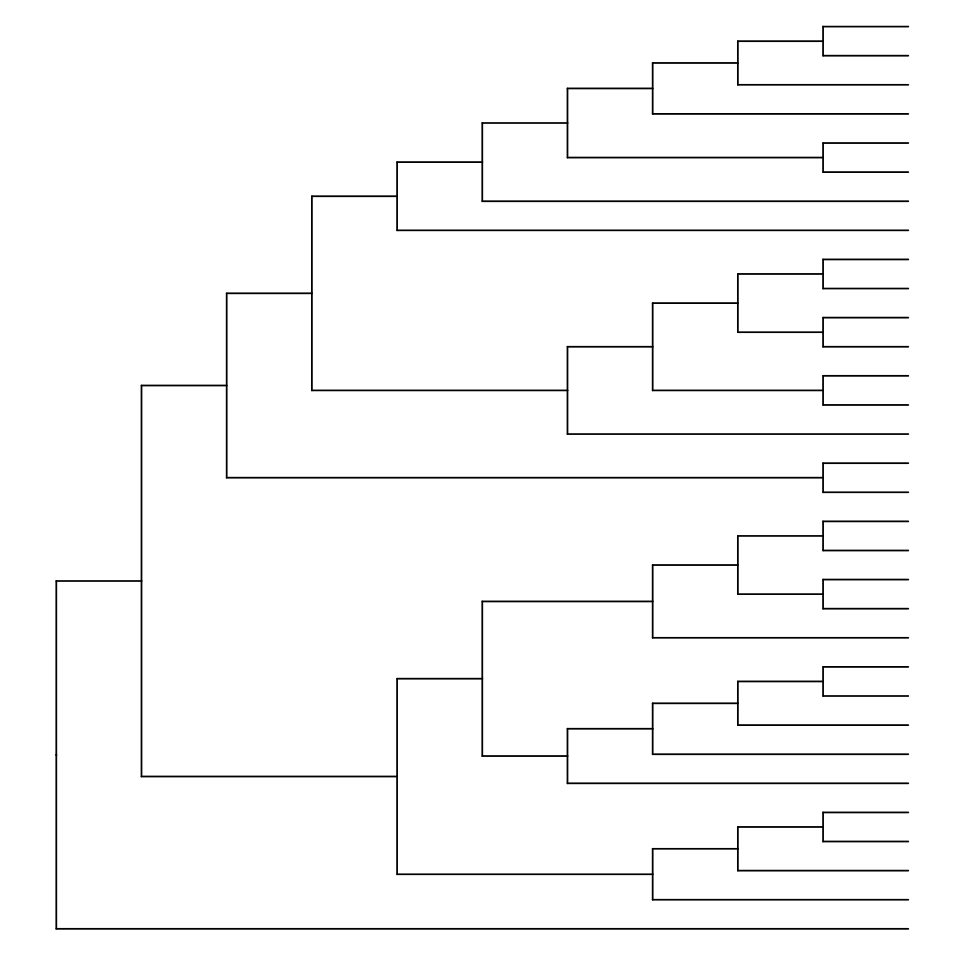

In [154]:
p = ggtree(spTre.subset,branch.length = "none") 
p

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_a.png"),height = 8,width = 8,
    units = "cm",res = 600,pointsize = 4)
p = ggtree(spTre.subset,branch.length = "none") %<+% merge_tab5
p = p + geom_tiplab(mapping = aes(label = correctSpecies),fontface = 'italic',size = 1.5)
p + geom_facet(panel = "Gene counts (x 1000)", data = helixerGeneCount, geom = geom_col,
            mapping = aes(x = count), orientation = 'y', width = .6)+
    theme_tree2(legend.position="none")+
    xlim_tree(xlim = c(0,25))+
    theme(strip.text.x.top = element_text(size =6),axis.text.x = element_text(size = 4))
dev.off()

In [178]:
numTaxa_helixer = apply(helixer_OG_filtered,1,function(x) sum(x>0))
table(numTaxa_helixer)                        

numTaxa_helixer
    1     2     3     4     5     6     7     8     9    10    11    12    13 
40190 10166  5596  3636  2517  1949  1336   908   656   493   384   349   255 
   14    15    16    17    18    19    20    21    22    23    24    25    26 
  233   195   191   167   173   151   180   182   199   224   214   199   271 
   27    28    29    30    31    32 
  291   345   468   978  3356 11389 

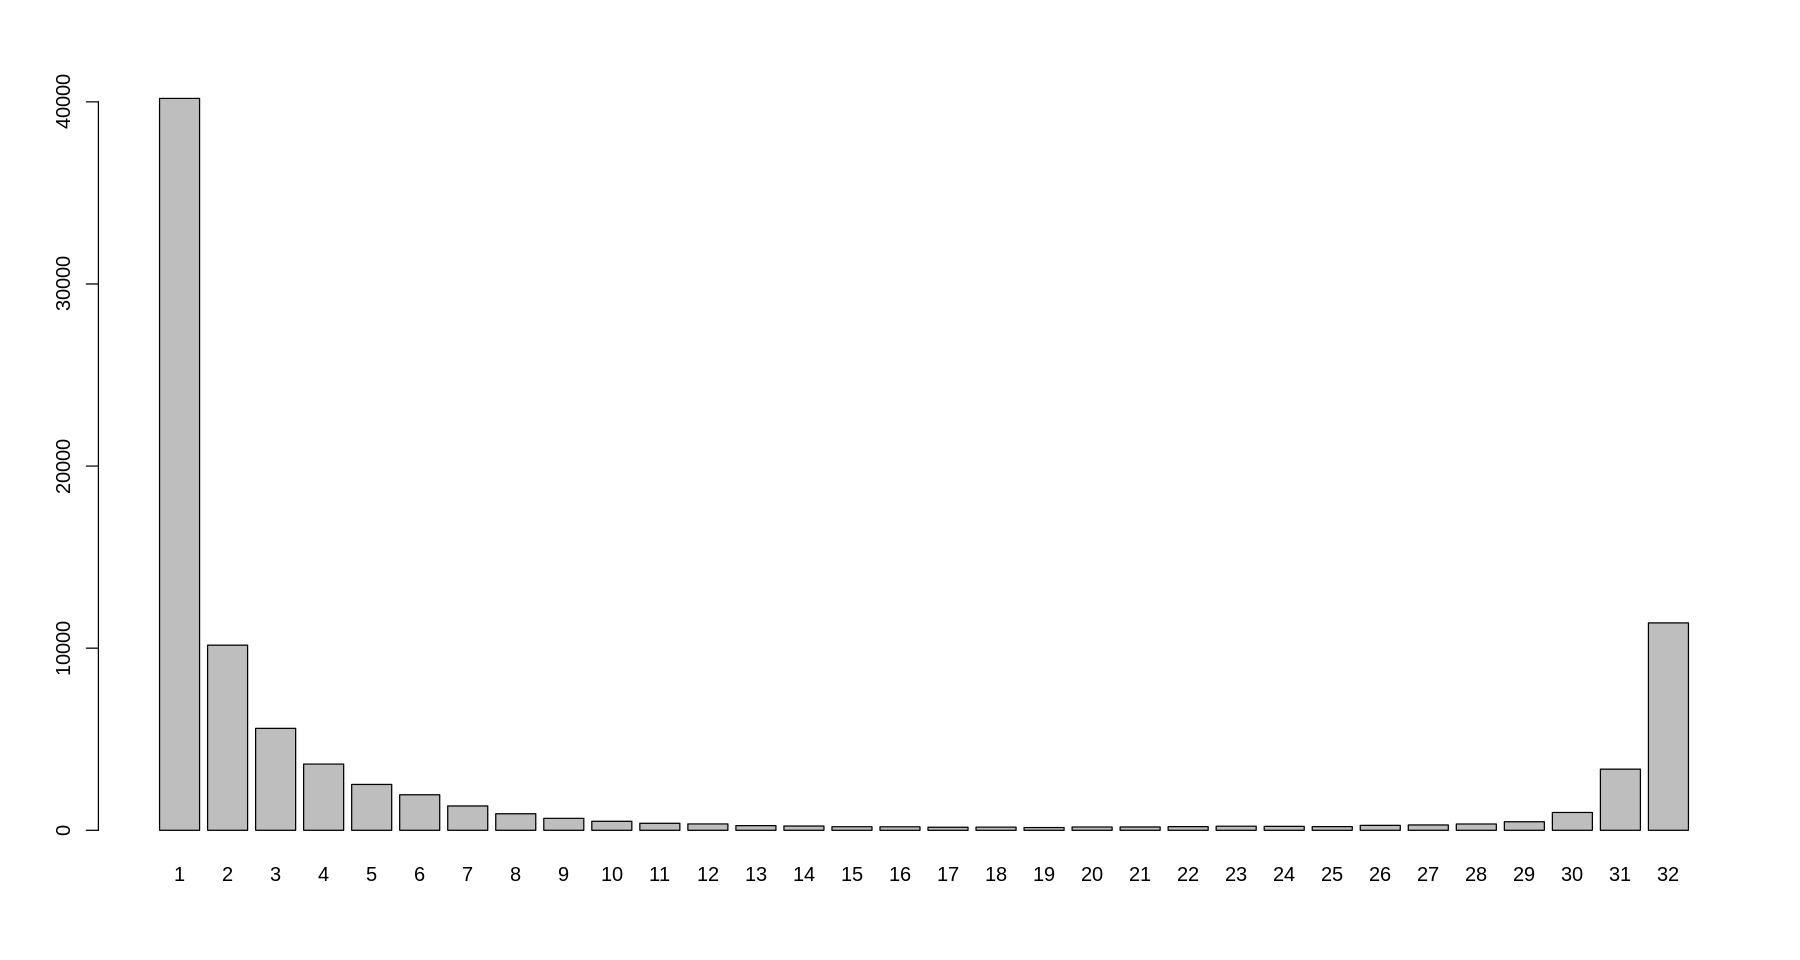

In [179]:
options(repr.plot.width=15, repr.plot.height=8)
barplot(table(numTaxa_helixer))

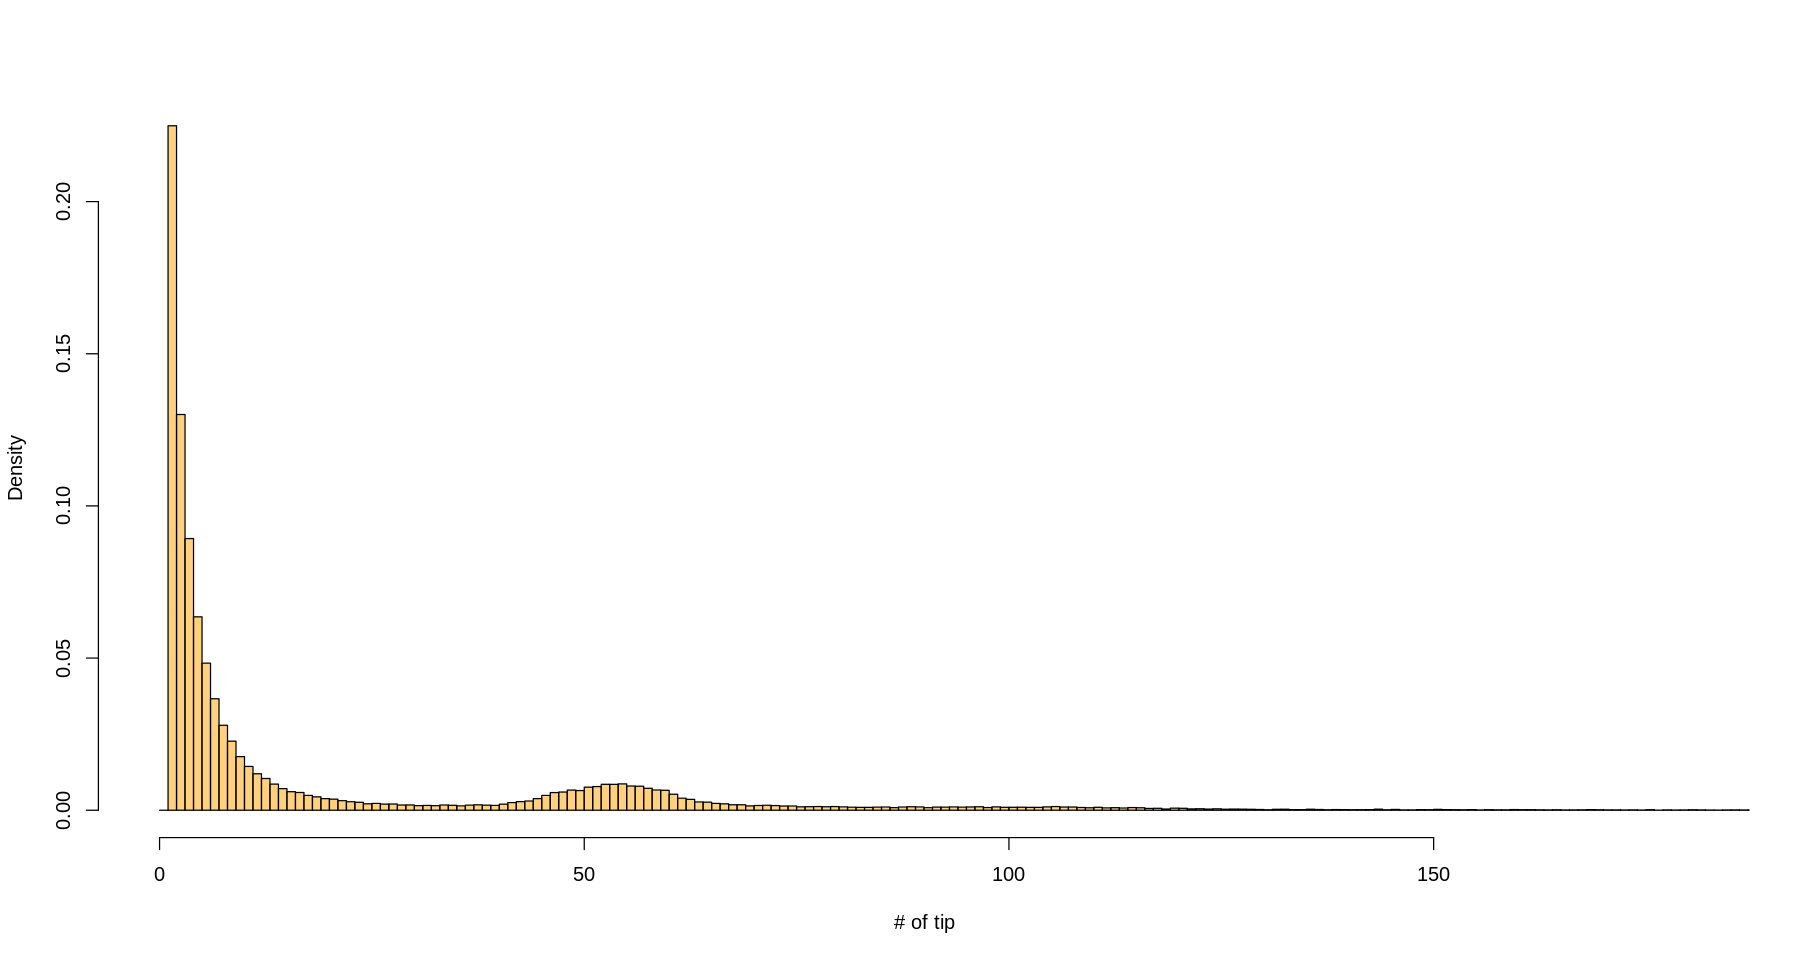

In [180]:
numTip_helixer = apply(helixer_OG_filtered,1,function(x) sum(x))

hist(numTip_helixer,xlim = c(0,180),breaks = seq(0,4000,1),xlab = "# of tip",main = "",
     col = scales::alpha("orange",.5),freq = F)


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   2.000    2.000    4.000    7.555    8.000 3022.000 

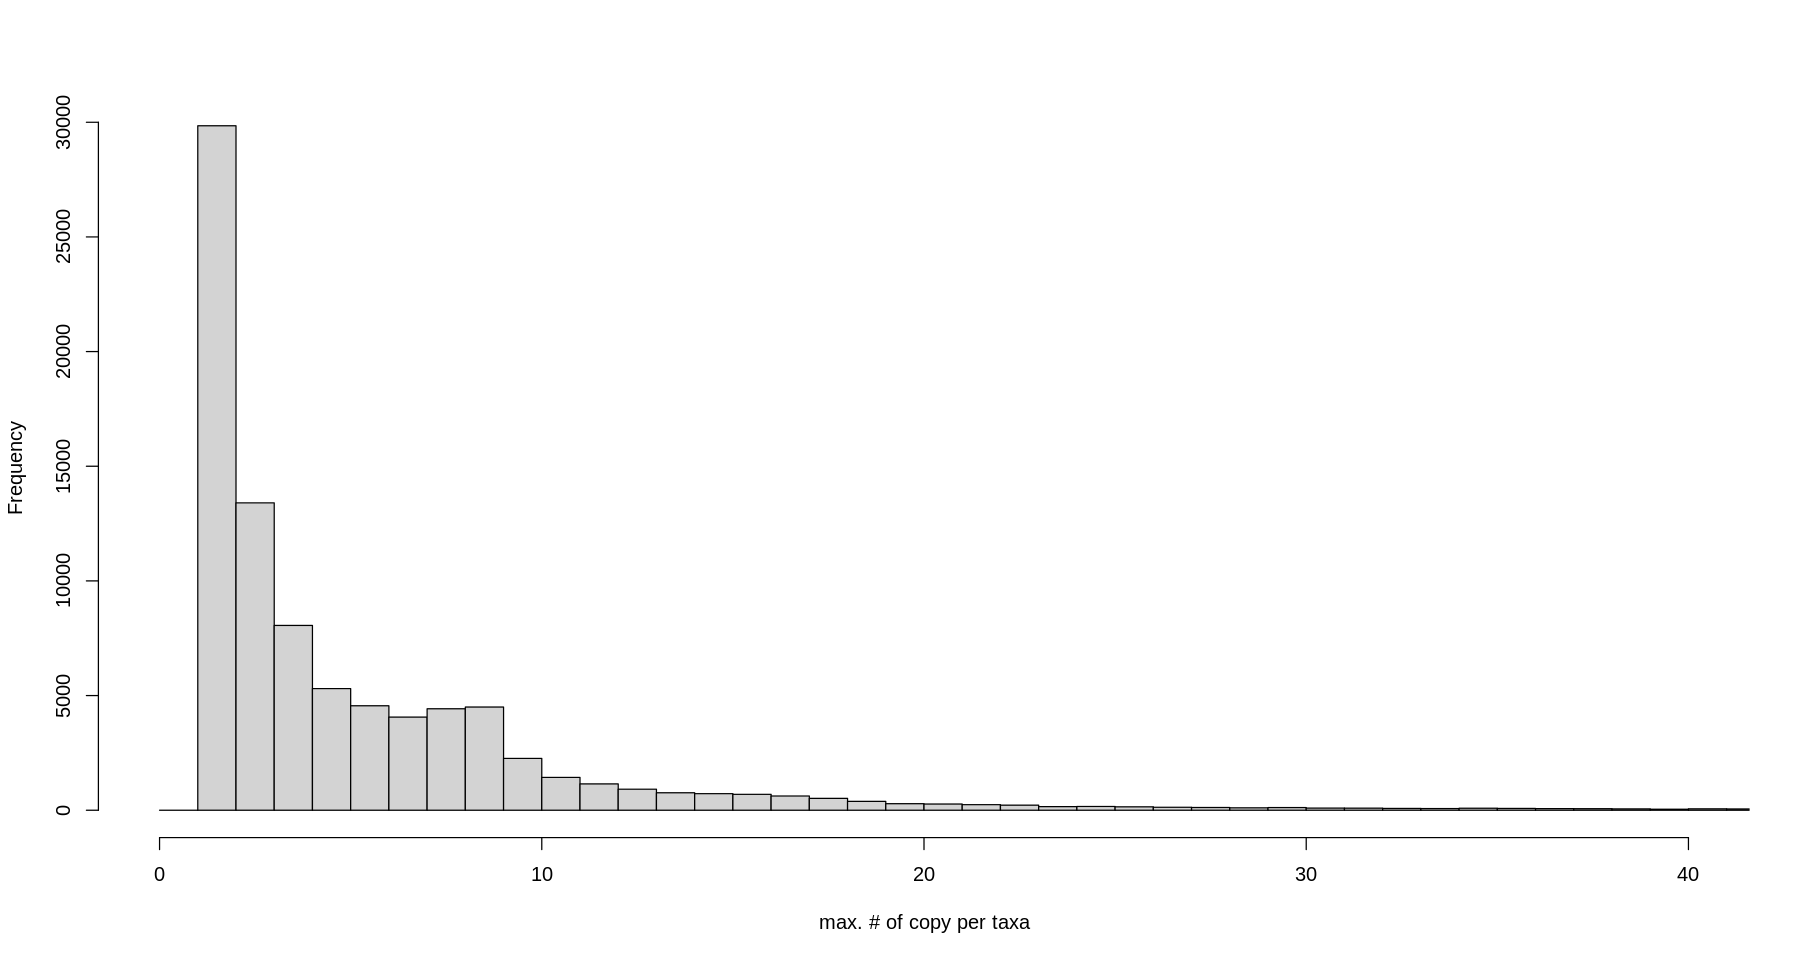

In [181]:
numTipMax_helixer = apply(helixer_OG_filtered,1,function(x) max(x))
summary(numTipMax_helixer)
hist(numTipMax_helixer,xlim = c(0,40),breaks = seq(0,3040,1),xlab = "max. # of copy per taxa",main = "")


In [201]:
library(pheatmap)
library(viridis)

Loading required package: viridisLite



In [ ]:
pheatmap(log10(table(numTaxa_helixer,numTipMax_helixer)[32:1,1:200]+1),cluster_row = F, cluster_col = F,
         color = viridis(100),show_rownames = F,show_colnames = F,
         filename = file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_b.png"),
         width = 8,height = 8,units = "cm",res = 600,pointsize = 4)

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_b3.png"),width = 6.6,height = 3,
    units = "cm",res = 600,pointsize = 4)
par(mar = c(4,4,1,0))
hist(numTipMax_helixer,breaks = seq(0,3040,1),xlab = "max. # of copy per taxa",main = "")
dev.off()
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_b4.png"),width = 4.4,height = 2,
    units = "cm",res = 600,pointsize = 4)
par(mar = c(2,3,0,0))
hist(numTipMax_helixer,xlim = c(0,100),breaks = seq(0,3040,1),main = "")
dev.off()

In [ ]:
# helixer-OG filtering

In [31]:
#filterOG = apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) sum(x>0))> 3 & !apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) any(x>18))

#filterOG_strict = apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) sum(x>0))> 7 & !apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) any(x>18))

# present in >= 8 taxa; with <= 100 copy per taxa
filterOG = apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) sum(x>0))> 7 & !apply(helixer_OG[,-c(1,ncol(helixer_OG))],1,function(x) any(x>100))

In [30]:
sum(filterOG)

[1] 22363

In [32]:
helixer_OG_OGfiltered = helixer_OG[filterOG,]

In [33]:
dim(helixer_OG)
dim(helixer_OG_OGfiltered)
# dim(helixer_OG_OGfilteredHard)
# dim(helixer_OG_recovered)

[1] 99140    34

[1] 22363    34

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_b1.png"),width = 6.6,height = 3,
    units = "cm",res = 600,pointsize = 4)
par(mar = c(4,4,1,0))
barplot(table(numTaxa_helixer),xlab = "Present in # of taxa",ylab = "# of OGs")
dev.off()
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_b2.png"),width = 4.4,height = 2,
    units = "cm",res = 600,pointsize = 4)
par(mar = c(2,3,0,0))
barplot(table(apply(helixer_OG_OGfiltered[,-c(1,ncol(helixer_OG))],1,function(x) sum(x>0))))
dev.off()

In [ ]:
pheatmap(numTipMax_helixer,numTaxa_helixer,cluster_rows = F,cluster_cols = F)

In [35]:
table(helixer_OG_OGfiltered[apply(helixer_OG_OGfiltered[,-c(1,ncol(helixer_OG))],1,function(x) sum(x>0))==32,"Sorghum_bicolor_NCBIv3.aa"])


   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
8047 2490  473  173   86   28   22   14    8    7    3    8    2    1    2    1 
  17   18   20   24   29 
   2    1    1    1    1 

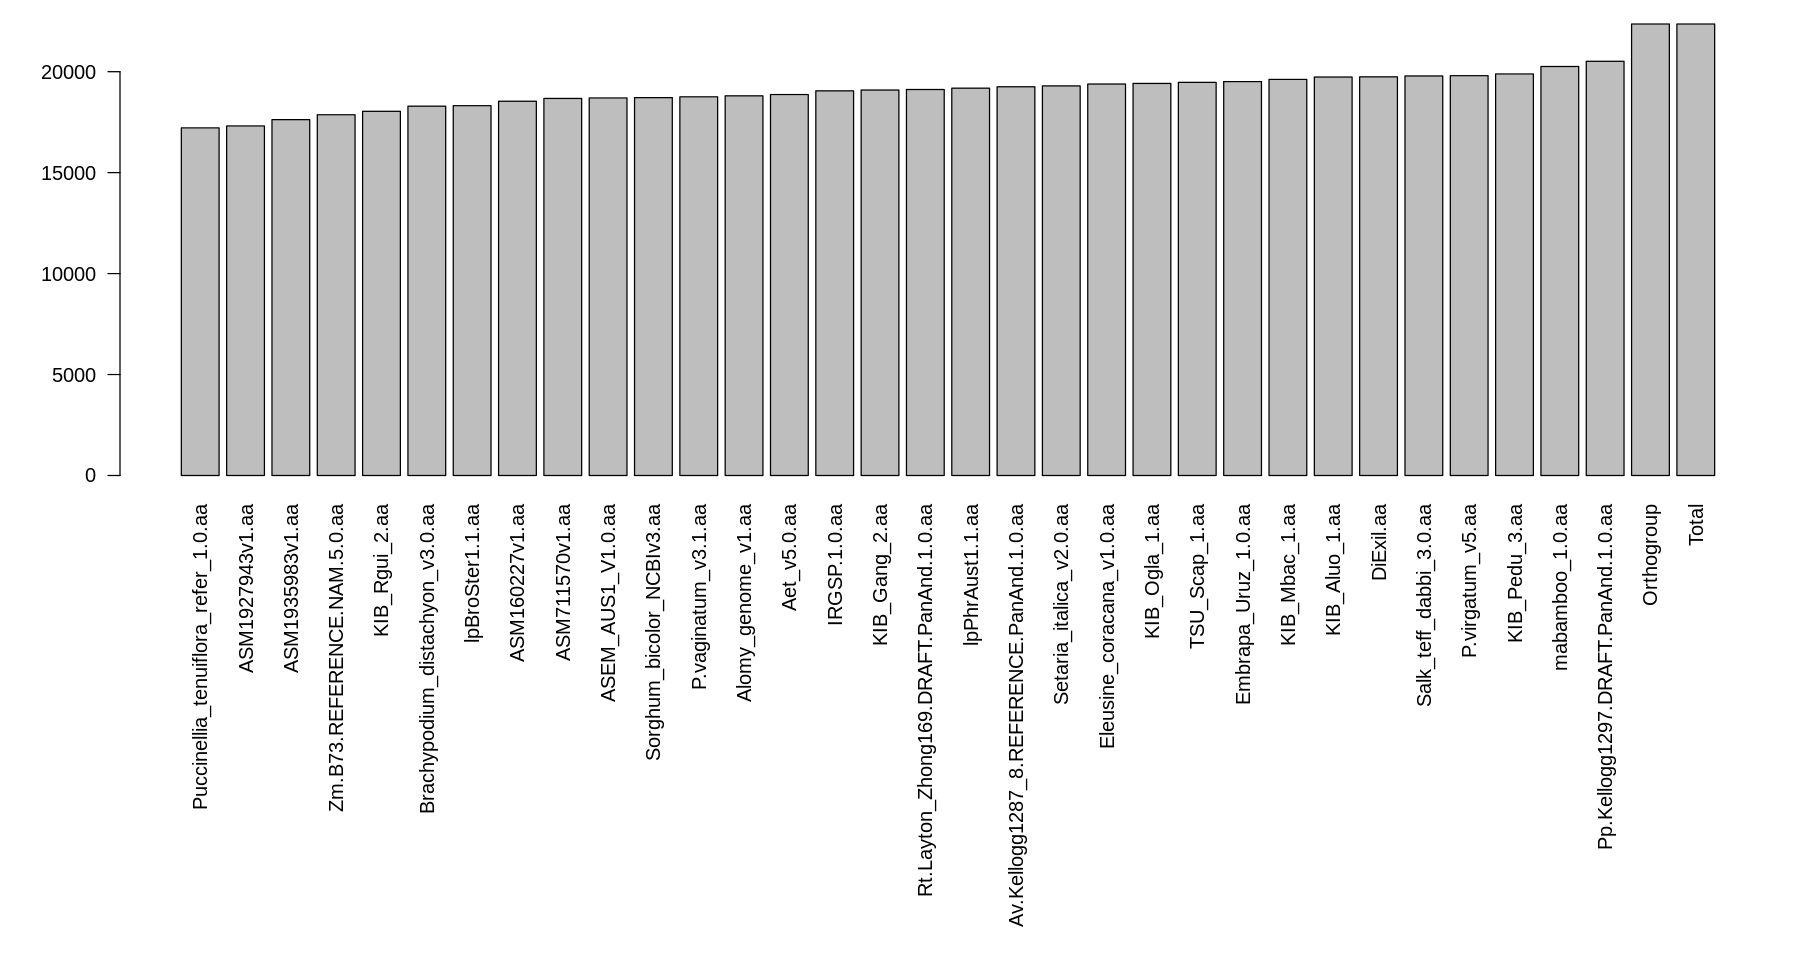

In [36]:
par(mar=c(20,5,1,1))
barplot(sort(colSums(helixer_OG_OGfiltered!=0)),las =2)

In [ ]:
write.table(helixer_OG_OGfiltered$Orthogroup,file.path(PHYLOGWAS_ROOT, "output/poaceaeHelixerOG_filtered_20250331.txt"),quote = F,col.names = F,row.names = F)

In [ ]:
####OG filter end####